# Exploratory Data Analysis

## Roles to Explore

In [7]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

### Filter for Kenya Data Analyst Roles

In [2]:
df_DA_Ke = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'Kenya')].copy()

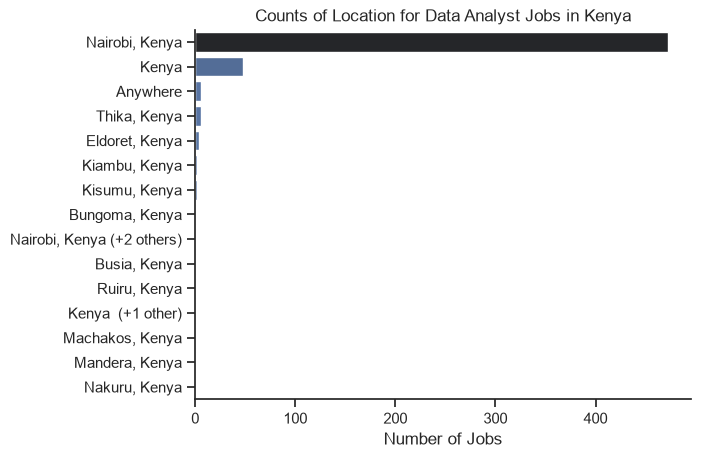

In [16]:
df_plot = df_DA_Ke['job_location'].value_counts().to_frame()

sns.set_theme(style='ticks')
sns.barplot(df_plot, x='count', y='job_location', hue='count', palette='dark:b_r', legend=False)
plt.title('Counts of Location for Data Analyst Jobs in Kenya')
plt.ylabel('')
plt.xlabel("Number of Jobs")
sns.despine()
plt.show()

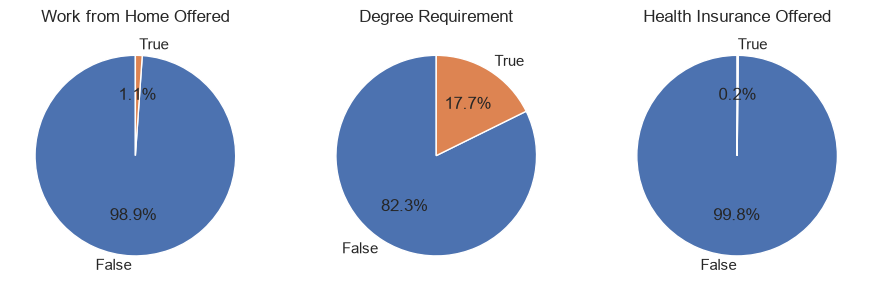

In [17]:
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3, figsize=(11, 3.5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_Ke[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

plt.show()

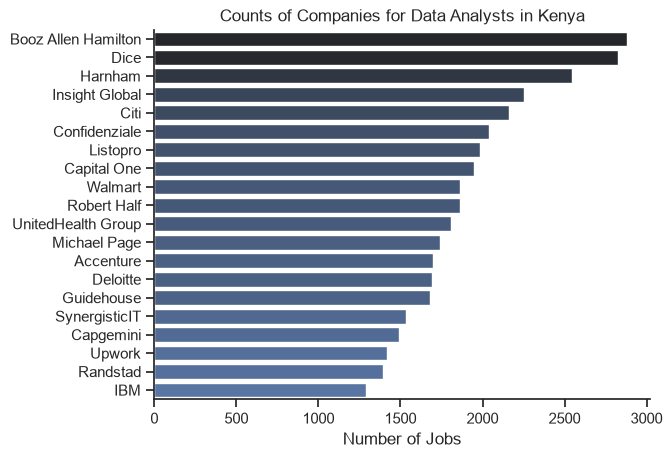

In [18]:
df_plot = df['company_name'].value_counts().to_frame()[1:].head(20)

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name', hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Companies for Data Analysts in Kenya')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()